In [1]:
import sys
print(sys.executable)

/Users/patcharapongvech/Desktop/Phet_folder/Year 3/Deep Learning/Proj./CNN/Project-1-Thai-Character-Number-Recognition/.venv/bin/python


## ขั้นที่ 1 — เช็ค dependency เทียบกับ `requirements.txt`
เทียบ version ที่ติดตั้งจริงใน `.venv` กับที่ pin ไว้ + เช็ค PyTorch MPS backend

In [3]:
import sys, re
from importlib.metadata import version, PackageNotFoundError
from pathlib import Path

PROJECT_ROOT = Path.cwd()
req_lines = [l.strip() for l in (PROJECT_ROOT / "requirements.txt").read_text().splitlines()
             if l.strip() and not l.startswith("#")]

missing, mismatch, ok = [], [], []
for line in req_lines:
    name, _, pinned = line.partition("==")
    try:
        installed = version(name)
    except PackageNotFoundError:
        missing.append(name); continue
    (ok if not pinned or installed == pinned else mismatch).append((name, pinned, installed))

print(f"Python: {sys.version.split()[0]}  ({sys.executable})")
print(f"requirements: {len(req_lines)} packages | OK {len(ok)} | version mismatch {len(mismatch)} | missing {len(missing)}")
for n, p, i in mismatch: print(f"  MISMATCH {n}: pinned {p}, installed {i}")
for n in missing: print(f"  MISSING  {n}")

# แพ็กเกจหลักที่โปรเจกต์ใช้จริง — ลอง import ทีละตัว
core = {"torch": "torch", "torchvision": "torchvision", "opencv-python": "cv2",
        "scikit-image": "skimage", "scikit-learn": "sklearn", "numpy": "numpy", "matplotlib": "matplotlib"}
for pkg, mod in core.items():
    try:
        m = __import__(mod); print(f"  import {mod:<12} OK  {getattr(m, '__version__', '')}")
    except Exception as e:
        print(f"  import {mod:<12} FAIL {e!r}")

import torch
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"MPS built={torch.backends.mps.is_built()} available={torch.backends.mps.is_available()} -> device = {device!r}")
print((torch.ones(2, device=device) * 2).cpu())  # smoke test บน device

Python: 3.14.7  (/Users/patcharapongvech/Desktop/Phet_folder/Year 3/Deep Learning/Proj./CNN/Project-1-Thai-Character-Number-Recognition/.venv/bin/python)
requirements: 124 packages | OK 124 | version mismatch 0 | missing 0
  import torch        OK  2.14.0
  import torchvision  OK  0.29.0
  import cv2          OK  5.0.0
  import skimage      OK  0.26.0
  import sklearn      OK  1.9.1
  import numpy        OK  2.5.3
  import matplotlib   OK  3.11.2
MPS built=True available=True -> device = 'mps'
tensor([2., 2.])


## ขั้นที่ 2 — สแกนโครงสร้างข้อมูลจริงใน `data/` (character, number, Mixed)
หมายเหตุ: โฟลเดอร์ข้อมูลจริงชื่อ `data/` (CLAUDE.md เขียนว่า `Dataset/`) — ผลทั้งหมดมาจากการสแกนไฟล์จริง ไม่อ้างอิง README เดิม
บันทึกผลเป็น `outputs/data_scan.csv` (1 แถว = 1 โฟลเดอร์ที่มีไฟล์)

In [4]:
import os, csv
from collections import Counter, defaultdict

DATA_ROOT = PROJECT_ROOT / "data"
OUT_DIR = PROJECT_ROOT / "outputs"; OUT_DIR.mkdir(exist_ok=True)
IGNORE = {".DS_Store"}

scan_rows = []   # (top, class_folder, subpath, ext, n_files)
for top in ["character", "number", "Mixed"]:
    top_dir = DATA_ROOT / top
    counts = defaultdict(Counter)   # relative dir -> Counter(ext)
    for dirpath, dirnames, filenames in os.walk(top_dir):
        rel = Path(dirpath).relative_to(top_dir)
        for f in filenames:
            if f in IGNORE: continue
            counts[rel][Path(f).suffix.lower() or "<none>"] += 1
    for rel, c in sorted(counts.items(), key=lambda kv: str(kv[0])):
        parts = rel.parts
        cls = parts[0] if parts else ""
        sub = "/".join(parts[1:]) if len(parts) > 1 else "(root)"
        for ext, n in sorted(c.items()):
            scan_rows.append((top, cls, sub, ext, n))

with open(OUT_DIR / "data_scan.csv", "w", newline="") as fh:
    w = csv.writer(fh); w.writerow(["top", "class_folder", "subpath", "ext", "n_files"]); w.writerows(scan_rows)

# ---------- สรุป ----------
for top in ["character", "number", "Mixed"]:
    rows = [r for r in scan_rows if r[0] == top]
    classes = sorted({r[1] for r in rows if r[1]}, key=lambda s: (not s.isdigit(), int(s) if s.isdigit() else s))
    print(f"\n===== data/{top}/ =====")
    print(f"ไฟล์ทั้งหมด {sum(r[4] for r in rows):,}")
    ext_tot = Counter(); [ext_tot.update({r[3]: r[4]}) for r in rows]
    print("นามสกุลรวม:", dict(ext_tot))
    print("subpath ที่พบ:", dict(Counter(r[2] for r in rows)))
    by_sub_ext = Counter(); [by_sub_ext.update({(r[2], r[3]): r[4]}) for r in rows]
    print("จำนวนไฟล์ตาม (subpath, ext):", dict(by_sub_ext))
    print(f"จำนวน class folder: {len(classes)} -> {classes[:3]} ... {classes[-3:]}" if classes else "ไม่มี subfolder (ไฟล์อยู่ที่ root)")


===== data/character/ =====
ไฟล์ทั้งหมด 153,445
นามสกุลรวม: {'.jpg': 139165, '.png': 14280}
subpath ที่พบ: {'D1': 66, 'D2': 68, 'D3': 67}
จำนวนไฟล์ตาม (subpath, ext): {('D1', '.jpg'): 62238, ('D2', '.jpg'): 76927, ('D3', '.png'): 14280}
จำนวน class folder: 71 -> ['161', '162', '163'] ... ['235', '236', '237']

===== data/number/ =====
ไฟล์ทั้งหมด 9,836
นามสกุลรวม: {'.jpg': 281, '.png': 9555}
subpath ที่พบ: {'D1': 10, 'D3': 10}
จำนวนไฟล์ตาม (subpath, ext): {('D1', '.jpg'): 281, ('D3', '.png'): 9555}
จำนวน class folder: 10 -> ['240', '241', '242'] ... ['247', '248', '249']

===== data/Mixed/ =====
ไฟล์ทั้งหมด 52
นามสกุลรวม: {'.jpg': 52}
subpath ที่พบ: {'(root)': 1}
จำนวนไฟล์ตาม (subpath, ext): {('(root)', '.jpg'): 52}
ไม่มี subfolder (ไฟล์อยู่ที่ root)


In [5]:
# รายละเอียดต่อ class folder: มี D1/D2/D3 ไหม, โฟลเดอร์ว่าง, ถอดรหัส TIS-620 เบื้องต้น, ชื่อไฟล์ตัวอย่าง, ขนาด/โหมดภาพ
from PIL import Image
import re

def tis(code):
    try: return bytes([int(code)]).decode("tis-620")
    except Exception: return "?"

for top in ["character", "number"]:
    top_dir = DATA_ROOT / top
    all_dirs = sorted([d.name for d in top_dir.iterdir() if d.is_dir()], key=int)
    have = defaultdict(set)
    for r in scan_rows:
        if r[0] == top: have[r[1]].add(r[2])
    empty = [d for d in all_dirs if d not in have]
    print(f"\n===== {top}: {len(all_dirs)} โฟลเดอร์, มีไฟล์ {len(have)}, ว่าง {len(empty)} =====")
    print("โฟลเดอร์ว่าง:", [(d, tis(d), sorted(p.name for p in (top_dir/d).iterdir())) for d in empty])
    print("ช่วงรหัสที่ไม่มีโฟลเดอร์เลย:", [c for c in range(int(all_dirs[0]), int(all_dirs[-1]) + 1) if str(c) not in all_dirs])
    for src in ["D1", "D2", "D3"]:
        miss = [f"{d}({tis(d)})" for d in have if src not in have[d]]
        print(f"  ไม่มี {src}: {len(miss)} คลาส -> {miss}")
    print("  คลาสที่มีไฟล์:", " ".join(f"{d}:{tis(d)}" for d in sorted(have, key=int)))

# ชื่อไฟล์ตัวอย่าง + pattern ชื่อ + ขนาด/โหมดภาพ (สุ่ม 200 ไฟล์ต่อ source)
import random; random.seed(0)
for top, src in [("character","D1"),("character","D2"),("character","D3"),("number","D1"),("number","D3"),("Mixed","")]:
    files = [p for p in (DATA_ROOT/top).rglob("*") if p.is_file() and p.name not in IGNORE and (not src or p.parent.name == src)]
    pat = Counter(re.sub(r"\d+", "#", p.stem) for p in files).most_common(3)
    sample = random.sample(files, min(200, len(files)))
    sizes, modes = Counter(), Counter()
    for p in sample:
        with Image.open(p) as im: sizes[im.size] += 1; modes[im.mode] += 1
    print(f"\n[{top}/{src or '(root)'}] n={len(files):,} ตัวอย่างชื่อ: {[p.relative_to(DATA_ROOT).as_posix() for p in files[:2]]}")
    print(f"   name patterns: {pat}")
    print(f"   modes: {dict(modes)} | sizes top5: {sizes.most_common(5)} | distinct sizes: {len(sizes)}")


===== character: 79 โฟลเดอร์, มีไฟล์ 71, ว่าง 8 =====
โฟลเดอร์ว่าง: [('218', 'ฺ', ['.DS_Store', 'D1', 'D2', 'D3']), ('219', '?', ['.DS_Store', 'D1', 'D2', 'D3']), ('220', '?', ['.DS_Store', 'D1', 'D2', 'D3']), ('221', '?', ['.DS_Store', 'D1', 'D2', 'D3']), ('222', '?', ['.DS_Store', 'D1', 'D2', 'D3']), ('223', '฿', ['.DS_Store', 'D1', 'D2', 'D3']), ('238', '๎', ['.DS_Store', 'D1', 'D2', 'D3']), ('239', '๏', ['.DS_Store', 'D1', 'D2', 'D3'])]
ช่วงรหัสที่ไม่มีโฟลเดอร์เลย: []
  ไม่มี D1: 5 คลาส -> ['166(ฆ)', '172(ฌ)', '198(ฦ)', '211(ำ)', '235(๋)']
  ไม่มี D2: 3 คลาส -> ['229(ๅ)', '230(ๆ)', '237(ํ)']
  ไม่มี D3: 4 คลาส -> ['164(ค)', '211(ำ)', '225(แ)', '229(ๅ)']
  คลาสที่มีไฟล์: 161:ก 162:ข 163:ฃ 164:ค 165:ฅ 166:ฆ 167:ง 168:จ 169:ฉ 170:ช 171:ซ 172:ฌ 173:ญ 174:ฎ 175:ฏ 176:ฐ 177:ฑ 178:ฒ 179:ณ 180:ด 181:ต 182:ถ 183:ท 184:ธ 185:น 186:บ 187:ป 188:ผ 189:ฝ 190:พ 191:ฟ 192:ภ 193:ม 194:ย 195:ร 196:ฤ 197:ล 198:ฦ 199:ว 200:ศ 201:ษ 202:ส 203:ห 204:ฬ 205:อ 206:ฮ 207:ฯ 208:ะ 209:ั 210:า 211:ำ 212:ิ 213:

In [6]:
# (ก) D3: ชื่อไฟล์ฝังรหัสคลาสไว้ (เช่น 24-185-B9-NO NU-813.png -> 185) — เทียบกับโฟลเดอร์ที่ไฟล์อยู่
d3_bad = []
for top in ["character", "number"]:
    for p in (DATA_ROOT / top).glob("*/D3/*.png"):
        code = p.name.split("-")[1]
        if code != p.parent.parent.name: d3_bad.append(p.relative_to(DATA_ROOT).as_posix())
print(f"D3 ไฟล์ที่รหัสในชื่อไม่ตรงโฟลเดอร์: {len(d3_bad)}", d3_bad[:10])

# (ข) Mixed/: ชื่อไฟล์ซ้ำกับไฟล์ใน class folder ไหน?
all_named = defaultdict(list)
for top in ["character", "number"]:
    for p in (DATA_ROOT / top).glob("*/D1/*"):
        all_named[p.name].append(p.parent.parent.name)
mixed = sorted(p.name for p in (DATA_ROOT / "Mixed").glob("*.jpg"))
hits = {n: all_named[n] for n in mixed if n in all_named}
print(f"Mixed: {len(mixed)} ไฟล์, ชื่อซ้ำกับ D1 ในโฟลเดอร์คลาส {len(hits)} ไฟล์ ->", list(hits.items())[:8])

# (ค) Polarity: mean brightness ต่อ source (สุ่ม 300 ไฟล์) — ใช้ตัดสินใจ normalize polarity ในขั้น 3
import numpy as np
for top, src in [("character","D1"),("character","D2"),("character","D3"),("number","D1"),("number","D3")]:
    pool = [p for p in (DATA_ROOT/top).glob(f"*/{src}/*") if p.name not in IGNORE]
    files = random.sample(pool, min(300, len(pool)))
    means = np.array([np.asarray(Image.open(p).convert("L"), dtype=np.float32).mean() for p in files])
    print(f"[{top}/{src}] mean brightness: median {np.median(means):.0f}, min {means.min():.0f}, max {means.max():.0f}, "
          f"สัดส่วน mean<128 (พื้นมืด) {np.mean(means < 128):.1%}")

D3 ไฟล์ที่รหัสในชื่อไม่ตรงโฟลเดอร์: 0 []
Mixed: 52 ไฟล์, ชื่อซ้ำกับ D1 ในโฟลเดอร์คลาส 0 ไฟล์ -> []
[character/D1] mean brightness: median 146, min 24, max 193, สัดส่วน mean<128 (พื้นมืด) 20.3%
[character/D2] mean brightness: median 252, min 240, max 254, สัดส่วน mean<128 (พื้นมืด) 0.0%
[character/D3] mean brightness: median 197, min 115, max 231, สัดส่วน mean<128 (พื้นมืด) 1.0%
[number/D1] mean brightness: median 138, min 83, max 180, สัดส่วน mean<128 (พื้นมืด) 33.8%
[number/D3] mean brightness: median 189, min 120, max 231, สัดส่วน mean<128 (พื้นมืด) 1.0%


### สรุปผลขั้นที่ 2 (จากการสแกนจริง 19 ก.ย. 2569)

| | CLAUDE.md ระบุ | ของจริง |
|---|---|---|
| root | `Dataset/character/` | `data/` มี `character/`, `number/`, `Mixed/`, `source/` |
| โครงสร้าง | `<รหัส>/D1,D2,D3/` | ตรง — แต่ตัวเลข 240–249 อยู่ใน `data/number/` แยก |
| นามสกุล | ยังไม่ยืนยัน | **D1 = `.jpg`** (L, crop แน่น, ~10–40 px), **D2 = `.jpg`** (RGB, ~140×140, มีขอบขาวเยอะ), **D3 = `.png`** (L, สี่เหลี่ยม ~20–45 px) |
| จำนวนคลาส | 72 | **81** = character 71 (ก–ฮ 44 + ฤ ฦ ฯ + สระ/วรรณยุกต์ 24) + number 10 |
| ไฟล์ | – | character 153,445 · number 9,836 · Mixed 52 (ไม่มี label) |

- `character/` มี 79 โฟลเดอร์ แต่ **8 โฟลเดอร์ว่าง** (218, 219–222 ไม่ใช่ตัวอักษร, 223 ฿, 238, 239) → ตัดทิ้ง
- ไม่มี D1: ฆ ฌ ฦ ำ ๋ · ไม่มี D2: ๅ ๆ ํ และตัวเลขทั้งหมด · ไม่มี D3: ค ำ แ ๅ → **ข้อที่ว่า "D1 ครบ 72 คลาส" ไม่จริง**
- D3 ชื่อไฟล์ฝังรหัสคลาส — ตรงกับโฟลเดอร์ 100%
- `Mixed/` 52 ไฟล์ ชื่อแบบ D1 แต่ไม่ซ้ำกับไฟล์ใน class folder — ภาพเป็นตัวติดกัน/สัญลักษณ์ ไม่มี label
- Polarity: ทุก source เป็นหมึกดำพื้นขาว; D1 ~20% มี mean<128 เพราะ crop แน่น+เส้นหนา **ไม่ได้กลับสี** → ขั้น 3 ต้องตัดสิน polarity จาก **ขอบภาพ** ไม่ใช่ mean ทั้งภาพ

**ยืนยันจากผู้ใช้ (19 ก.ย.)**: D1 = dataset อาจารย์, **D2 = Burapha-TH**, **D3 = THI-C168** (สลับกับที่ CLAUDE.md เขียน) · `Mixed/` ข้ามไปก่อน
· เป้าหมาย 72 คลาส แต่ข้อมูลจริงมีคลาสที่มีภาพ 81 คลาส (71+10) — ยังต้องเคลียร์

## ขั้นที่ 3 — Class mapping (TIS-620) + Preprocessing pipeline
**อ่านไฟล์ตามโครงสร้างจริงจากขั้น 2**: `data/{character,number}/<รหัส TIS-620>/{D1,D2,D3}/*.{jpg,png}` — ข้ามโฟลเดอร์ว่าง, `Mixed/`, `.DS_Store`
Class index 0..N-1 = เรียงรหัสโฟลเดอร์น้อย→มาก จากโฟลเดอร์ที่ **มีภาพจริง** (N คำนวณจากข้อมูล ไม่ hardcode)

In [7]:
SOURCE_NAME = {"D1": "Teacher", "D2": "Burapha-TH", "D3": "THI-C168"}   # ยืนยันโดยผู้ใช้
IMG_EXTS = {".jpg", ".jpeg", ".png"}

def tis620_char(code: int) -> str:
    """รหัสโฟลเดอร์ (TIS-620 byte) -> ตัวอักษรไทย เช่น 161 -> 'ก'"""
    return bytes([int(code)]).decode("tis-620")

def build_index(data_root=DATA_ROOT, tops=("character", "number")):
    """คืน list ของ (path, code, source) จากโครงสร้างจริง <top>/<code>/<D1|D2|D3>/<file>"""
    items = []
    for top in tops:
        for cls_dir in sorted((data_root / top).iterdir(), key=lambda d: d.name):
            if not (cls_dir.is_dir() and cls_dir.name.isdigit()): continue
            for src_dir in sorted(cls_dir.iterdir()):
                if not (src_dir.is_dir() and src_dir.name in SOURCE_NAME): continue
                for f in sorted(src_dir.iterdir()):
                    if f.suffix.lower() in IMG_EXTS:
                        items.append((f, int(cls_dir.name), src_dir.name))
    return items

index = build_index()
CLASS_CODES = sorted({code for _, code, _ in index})          # เฉพาะโฟลเดอร์ที่มีภาพ
CODE_TO_IDX = {c: i for i, c in enumerate(CLASS_CODES)}
IDX_TO_CHAR = [tis620_char(c) for c in CLASS_CODES]
NUM_CLASSES = len(CLASS_CODES)
samples = [(p, CODE_TO_IDX[c], s) for p, c, s in index]      # (path, label, source)

print(f"ภาพทั้งหมด {len(samples):,} | NUM_CLASSES = {NUM_CLASSES}")
print(" ".join(f"{i}:{ch}" for i, ch in enumerate(IDX_TO_CHAR)))

ภาพทั้งหมด 163,281 | NUM_CLASSES = 81
0:ก 1:ข 2:ฃ 3:ค 4:ฅ 5:ฆ 6:ง 7:จ 8:ฉ 9:ช 10:ซ 11:ฌ 12:ญ 13:ฎ 14:ฏ 15:ฐ 16:ฑ 17:ฒ 18:ณ 19:ด 20:ต 21:ถ 22:ท 23:ธ 24:น 25:บ 26:ป 27:ผ 28:ฝ 29:พ 30:ฟ 31:ภ 32:ม 33:ย 34:ร 35:ฤ 36:ล 37:ฦ 38:ว 39:ศ 40:ษ 41:ส 42:ห 43:ฬ 44:อ 45:ฮ 46:ฯ 47:ะ 48:ั 49:า 50:ำ 51:ิ 52:ี 53:ึ 54:ื 55:ุ 56:ู 57:เ 58:แ 59:โ 60:ใ 61:ไ 62:ๅ 63:ๆ 64:็ 65:่ 66:้ 67:๊ 68:๋ 69:์ 70:ํ 71:๐ 72:๑ 73:๒ 74:๓ 75:๔ 76:๕ 77:๖ 78:๗ 79:๘ 80:๙


In [8]:
import cv2
import numpy as np
from skimage.filters import threshold_sauvola
from skimage.measure import label as cc_label

TARGET = 64      # ขนาดภาพสุดท้าย
MARGIN = 4       # เว้นขอบ -> ตัวอักษรยาวสุด = TARGET - 2*MARGIN

def load_gray(path) -> np.ndarray:
    """อ่านเป็น grayscale uint8 (D2 เป็น RGB, D1/D3 เป็น L)"""
    with Image.open(path) as im:
        return np.asarray(im.convert("L"), dtype=np.uint8)

def border_dark_fraction(g: np.ndarray) -> float:
    return float((np.concatenate([g[0], g[-1], g[:, 0], g[:, -1]]) < 128).mean())

def normalize_polarity(g: np.ndarray) -> np.ndarray:
    """1) ทำให้เป็น 'หมึกเข้ม พื้นสว่าง'
    สแกนทั้ง dataset แล้ว: ไม่มีภาพที่กลับสีจริง แต่ D1 crop แน่น+เส้นหนา -> ขอบมืดได้ถึง 94% (เช่น ่ ทั้งภาพเป็นหมึก)
    ทั้ง mean<128 และ median ขอบ<128 จึงใช้ไม่ได้ (จะกลับสีผิด ~6,300 ภาพ)
    -> กลับสีเฉพาะเมื่อขอบมืด >= 97% (พื้นหลังมืดจริง) — กันไว้สำหรับ test set ของอาจารย์"""
    if int(g.max()) - int(g.min()) < 30: return g         # ภาพสีเดียว ไม่มีพื้นให้อ้างอิง -> ไม่กลับสี
    return 255 - g if border_dark_fraction(g) >= 0.97 else g

def sauvola_binarize(g: np.ndarray, k: float = 0.2) -> np.ndarray:
    """2) Sauvola -> mask หมึก (True = หมึก)
    + guard: ไม่นับพิกเซลที่ต่างจากพื้น (percentile 99) น้อยกว่า 30 (กันกรอบจางใน D2 / JPEG noise)
    + รวมพิกเซลที่มืดกว่าครึ่งหนึ่งของพื้น (กัน Sauvola เจาะรูกลางเส้นหนาใน D1)"""
    if int(g.max()) - int(g.min()) < 30:                   # ภาพสีเดียว: D1 '่' ที่ crop แล้วเป็นหมึกทั้งภาพ (58 ภาพ)
        return np.full(g.shape, g.mean() < 128)
    h, w = g.shape
    win = max(3, min(25, (min(h, w) // 2) | 1))           # เลขคี่ ปรับตามขนาดภาพ (D1 เล็กมาก)
    t = threshold_sauvola(g, window_size=win, k=k)
    bg = float(np.percentile(g, 99))                      # ความสว่างพื้น (ไม่ใช้ขอบ — ขอบ D1 อาจเป็นหมึก)
    ink = ((g < t) | (g < 0.5 * bg)) & (g < bg - 30)
    # ลบจุด noise ที่เล็กกว่า 1% ของหมึกทั้งหมด (ไม่ใช้ขนาดคงที่ เพราะวรรณยุกต์ทั้งภาพก็เล็ก)
    lab = cc_label(ink, connectivity=2)
    if lab.max() > 1:
        areas = np.bincount(lab.ravel()); areas[0] = 0
        ink = np.isin(lab, np.flatnonzero(areas >= 0.01 * areas.sum()))
    return ink

def tight_crop(mask: np.ndarray) -> np.ndarray:
    """3) ตัดให้ชิดขอบหมึก"""
    ys, xs = np.nonzero(mask)
    if len(ys) == 0: return mask                           # ภาพว่าง -> คืนเดิม
    return mask[ys.min():ys.max() + 1, xs.min():xs.max() + 1]

def resize_keep_aspect(mask: np.ndarray, box: int = TARGET - 2 * MARGIN) -> np.ndarray:
    """4) ย่อ/ขยายให้ด้านยาวสุด = box โดยคงสัดส่วน -> uint8 (หมึก=255)"""
    h, w = mask.shape
    s = box / max(h, w)
    nh, nw = max(1, round(h * s)), max(1, round(w * s))
    interp = cv2.INTER_AREA if s < 1 else cv2.INTER_LINEAR
    return cv2.resize(mask.astype(np.uint8) * 255, (nw, nh), interpolation=interp)

def letterbox_centroid(glyph: np.ndarray, size: int = TARGET) -> np.ndarray:
    """5) วางลง canvas size×size ให้ centroid ของหมึกอยู่กลาง canvas (clamp ไม่ให้หลุดขอบ)"""
    h, w = glyph.shape
    m = cv2.moments(glyph, binaryImage=False)
    cy, cx = (m["m01"] / m["m00"], m["m10"] / m["m00"]) if m["m00"] > 0 else (h / 2, w / 2)
    top  = int(np.clip(round(size / 2 - cy), 0, size - h))
    left = int(np.clip(round(size / 2 - cx), 0, size - w))
    canvas = np.zeros((size, size), np.uint8)
    canvas[top:top + h, left:left + w] = glyph
    return canvas

def preprocess(path, return_steps: bool = False):
    """pipeline เต็ม: path -> uint8 (TARGET×TARGET), หมึก=255 พื้น=0"""
    g0 = load_gray(path)
    g1 = normalize_polarity(g0)
    m2 = sauvola_binarize(g1)
    m3 = tight_crop(m2)
    g4 = resize_keep_aspect(m3)
    out = letterbox_centroid(g4)
    return (out, [g0, g1, m2, m3, g4, out]) if return_steps else out

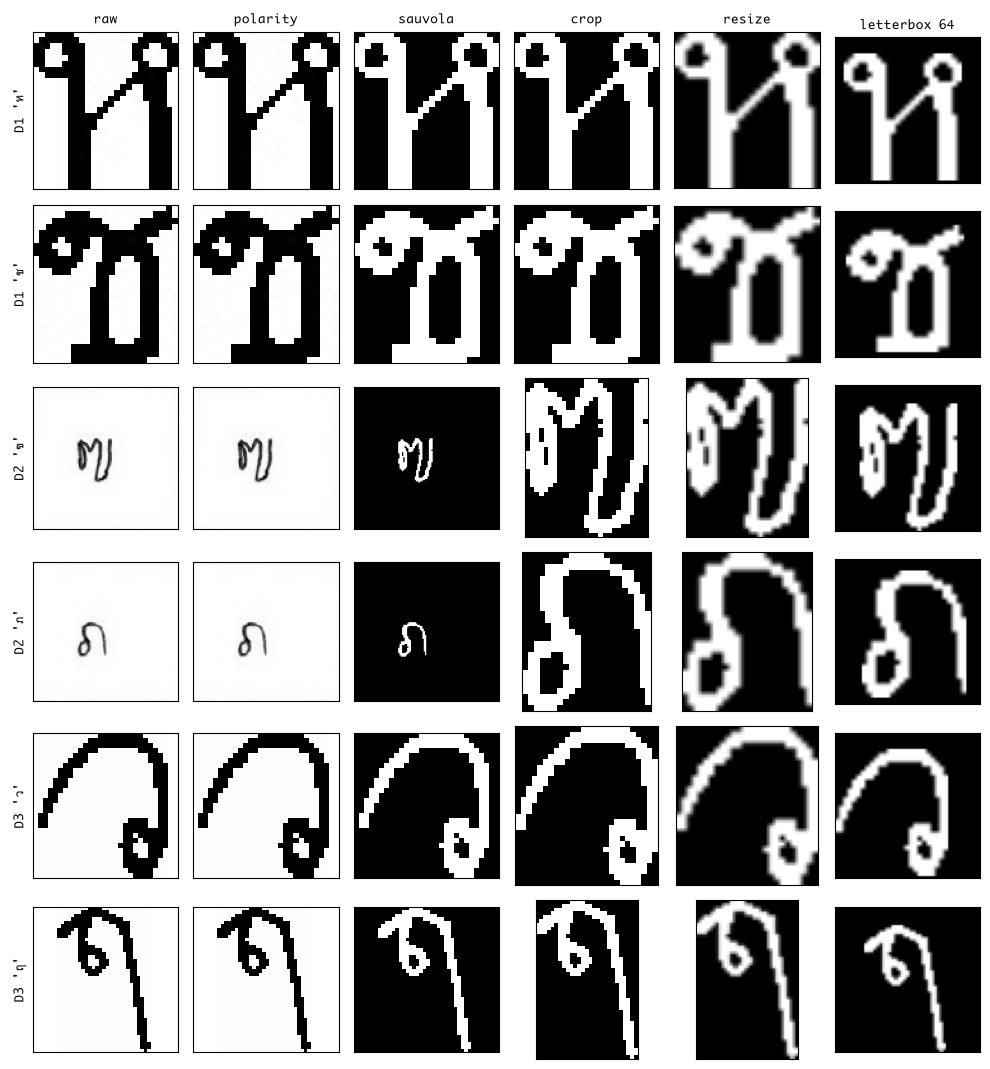

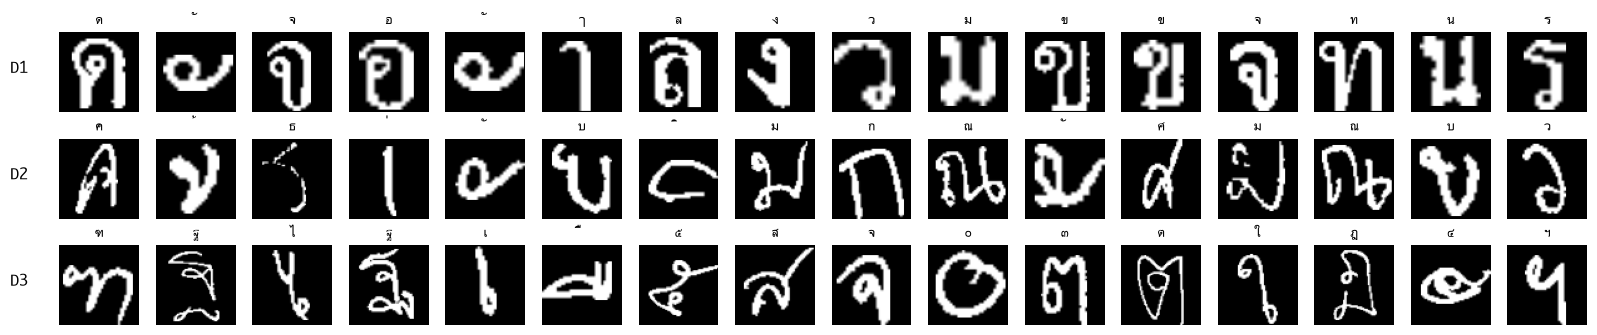

เวลาเฉลี่ย 9.0 ms/ภาพ (รวมวาดกราฟ)
ตรวจ 163,281 ภาพ ใน 97s | ผลลัพธ์ว่าง: 3 | ถูกกลับสี: 0
['character/162/D2/Set5_F1_P-0166_1.jpg', 'character/209/D2/Set5_F1_P-0166_123.jpg', 'character/225/D2/Set5_F1_P-0166_133.jpg']


In [9]:
# ตรวจด้วยตา: แต่ละ step ของ pipeline — สุ่มจากทุก source (รวม D1 เส้นหนา/crop แน่น และ D2 เส้นดินสอจาง)
import matplotlib.pyplot as plt
from matplotlib import font_manager
for f in ["/System/Library/Fonts/Supplemental/Ayuthaya.ttf", "/System/Library/Fonts/Thonburi.ttc"]:   # ฟอนต์ไทยของ macOS
    if Path(f).exists():
        font_manager.fontManager.addfont(f); plt.rcParams["font.family"] = font_manager.FontProperties(fname=f).get_name(); break
random.seed(42)
by_src = defaultdict(list)
for p, y, s in samples: by_src[s].append((p, y))
demo = [(s, *random.choice(by_src[s])) for s in ["D1", "D1", "D2", "D2", "D3", "D3"]]
step_names = ["raw", "polarity", "sauvola", "crop", "resize", f"letterbox {TARGET}"]
fig, axes = plt.subplots(len(demo), 6, figsize=(10, 1.8 * len(demo)))
for r, (s, p, y) in enumerate(demo):
    _, steps = preprocess(p, return_steps=True)
    for c, img in enumerate(steps):
        ax = axes[r, c]; ax.imshow(img, cmap="gray"); ax.set_xticks([]); ax.set_yticks([])
        if r == 0: ax.set_title(step_names[c], fontsize=9)
    axes[r, 0].set_ylabel(f"{s} '{IDX_TO_CHAR[y]}'", fontsize=9)
plt.tight_layout(); plt.savefig(OUT_DIR / "preprocess_steps.png", dpi=120); plt.show()

# ภาพผลลัพธ์สุดท้ายจำนวนมาก (สุ่ม 8 ภาพ/source) + เวลาเฉลี่ย/ภาพ
import time
fig, axes = plt.subplots(3, 16, figsize=(16, 3.4))
t0, n = time.perf_counter(), 0
for r, s in enumerate(["D1", "D2", "D3"]):
    for c, (p, y) in enumerate(random.sample(by_src[s], 16)):
        axes[r, c].imshow(preprocess(p), cmap="gray"); axes[r, c].axis("off"); n += 1
        axes[r, c].set_title(IDX_TO_CHAR[y], fontsize=10)
    axes[r, 0].text(-40, 32, s, fontsize=11)
plt.tight_layout(); plt.savefig(OUT_DIR / "preprocess_grid.png", dpi=120); plt.show()
print(f"เวลาเฉลี่ย {1000 * (time.perf_counter() - t0) / n:.1f} ms/ภาพ (รวมวาดกราฟ)")

# ตรวจทั้ง dataset: ภาพที่ผลลัพธ์ว่าง + ภาพที่ถูกกลับสี (ควรเป็น 0 ทั้งคู่ เพราะไม่มีภาพกลับสีจริง) — ~1-2 นาที
t0 = time.perf_counter()
empty, inverted = [], []
for p, _, _ in samples:
    g = load_gray(p)
    if border_dark_fraction(g) >= 0.97 and int(g.max()) - int(g.min()) >= 30: inverted.append(p)
    if preprocess(p).max() == 0: empty.append(p)
print(f"ตรวจ {len(samples):,} ภาพ ใน {time.perf_counter() - t0:.0f}s | ผลลัพธ์ว่าง: {len(empty)} | ถูกกลับสี: {len(inverted)}")
print([x.relative_to(DATA_ROOT).as_posix() for x in (empty + inverted)[:10]])

### สรุปผลขั้นที่ 3
- `preprocess(path)` -> uint8 64×64 หมึก=255 พื้น=0 · ~9 ms/ภาพ (163k ภาพ ≈ 25 นาทีถ้าทำครั้งเดียว)
- **Polarity**: ทั้ง dataset ไม่มีภาพกลับสีจริง — แต่ D1 6,341 ภาพมี *ขอบ* มืด (crop แน่น+เส้นหนา) → กลับสีเฉพาะเมื่อขอบมืด ≥97% (ตรวจทั้ง dataset: ถูกกลับสี 0 ภาพ)
- **ภาพสีเดียว**: D1 `่` 58 ภาพเป็นแท่งดำทั้งภาพ → ถือเป็นหมึกทั้งภาพ
- **ภาพเสีย**: D2 ว่างเปล่า 3 ภาพ (`Set5_F1_P-0166_{1,123,133}.jpg` ใน 162, 209, 225) → ควรตัดออกตอนสร้าง dataset
- สังเกต: ความหนาเส้นต่างกันมากระหว่าง source (D1 หนา, D2/D3 บาง) · D2 เส้นดินสอจางบางภาพขาดเป็นท่อน

## ขั้นที่ 4 — Sanity check TIS-620 + จำนวนภาพต่อคลาสต่อ source
ใช้ได้ใน presentation (จำนวนคลาส / ตัวอย่างต่อคลาส / ความไม่สมดุล) — ยืนยันจากผู้ใช้: **81 คลาส**

In [10]:
import unicodedata

# (1) 4 จุดตามที่กำหนด
expected = {161: "ก", 206: "ฮ", 240: "๐", 249: "๙"}
for code, ch in expected.items():
    got = tis620_char(code)
    print(f"{code} -> {got!r} (U+{ord(got):04X} {unicodedata.name(got)})  คาดหวัง {ch!r}  {'OK' if got == ch else 'FAIL'}")

# (2) ตรวจทุกคลาส: TIS-620 ไทยอยู่ที่ byte 0xA1-0xFB = Unicode U+0E01-U+0E5B (offset คงที่ 0xD60)
bad = [c for c in CLASS_CODES if tis620_char(c) != chr(c + 0xD60)]
print(f"\nตรวจ {len(CLASS_CODES)} คลาส กับสูตร U+0E00 + (code - 0xA0): ไม่ตรง {len(bad)} คลาส")
for c in (224, 225, 208, 232):   # ตัวอย่างสระ/วรรณยุกต์ที่มักสับสน
    print(f"  {c} -> {tis620_char(c)!r} {unicodedata.name(tis620_char(c))}")

161 -> 'ก' (U+0E01 THAI CHARACTER KO KAI)  คาดหวัง 'ก'  OK
206 -> 'ฮ' (U+0E2E THAI CHARACTER HO NOKHUK)  คาดหวัง 'ฮ'  OK
240 -> '๐' (U+0E50 THAI DIGIT ZERO)  คาดหวัง '๐'  OK
249 -> '๙' (U+0E59 THAI DIGIT NINE)  คาดหวัง '๙'  OK

ตรวจ 81 คลาส กับสูตร U+0E00 + (code - 0xA0): ไม่ตรง 0 คลาส
  224 -> 'เ' THAI CHARACTER SARA E
  225 -> 'แ' THAI CHARACTER SARA AE
  208 -> 'ะ' THAI CHARACTER SARA A
  232 -> '่' THAI CHARACTER MAI EK


In [11]:
# (3) นับจำนวนภาพต่อคลาสต่อ source (ตัดภาพว่าง 3 ภาพจากขั้น 3 ออก)
BLANK = {Path(p) for p in empty}
SRCS = ["D1", "D2", "D3"]
counts = np.zeros((NUM_CLASSES, 3), dtype=int)
for p, y, s in samples:
    if p not in BLANK: counts[y, SRCS.index(s)] += 1
totals = counts.sum(1)

with open(OUT_DIR / "class_counts.csv", "w", newline="", encoding="utf-8-sig") as fh:   # utf-8-sig ให้ Excel อ่านไทยได้
    w = csv.writer(fh)
    w.writerow(["idx", "tis620_code", "char", "unicode_name", *[f"{s} ({SOURCE_NAME[s]})" for s in SRCS], "total"])
    for i, c in enumerate(CLASS_CODES):
        w.writerow([i, c, IDX_TO_CHAR[i], unicodedata.name(IDX_TO_CHAR[i]), *counts[i], totals[i]])

print(f"{'idx':>3} {'code':>4} {'ch':^3} {'D1':>6} {'D2':>6} {'D3':>6} {'total':>6}")
for i, c in enumerate(CLASS_CODES):
    print(f"{i:>3} {c:>4}  {IDX_TO_CHAR[i]:^2} {counts[i,0]:>6} {counts[i,1]:>6} {counts[i,2]:>6} {totals[i]:>6}")
print(f"{'รวม':>12} {counts[:,0].sum():>6} {counts[:,1].sum():>6} {counts[:,2].sum():>6} {totals.sum():>6}")

print(f"\nภาพต่อคลาส: min {totals.min()} ({IDX_TO_CHAR[totals.argmin()]}) | median {int(np.median(totals))} | "
      f"max {totals.max()} ({IDX_TO_CHAR[totals.argmax()]}) | imbalance max/min = {totals.max() / totals.min():.1f}x")
low = [(IDX_TO_CHAR[i], totals[i]) for i in np.argsort(totals) if totals[i] < 0.5 * np.median(totals)]
print(f"คลาสที่น้อยกว่าครึ่งหนึ่งของ median ({len(low)}):", low)
one_src = [(IDX_TO_CHAR[i], [s for j, s in enumerate(SRCS) if counts[i, j]]) for i in range(NUM_CLASSES) if (counts[i] > 0).sum() == 1]
print(f"คลาสที่มีแค่ source เดียว ({len(one_src)}):", one_src)

idx code ch      D1     D2     D3  total
  0  161  ก    1941   1143    218   3302
  1  162  ข    1349   1139    221   2709
  2  163  ฃ       1   1055    212   1268
  3  164  ค    1454   1126      0   2580
  4  165  ฅ       7   1110    208   1325
  5  166  ฆ       0   1134    206   1340
  6  167  ง    1078   1146    219   2443
  7  168  จ    1222   1137    217   2576
  8  169  ฉ      44   1129    203   1376
  9  170  ช    1012   1161    210   2383
 10  171  ซ     301   1146    208   1655
 11  172  ฌ       0   1121    207   1328
 12  173  ญ     113   1119    213   1445
 13  174  ฎ       3   1135    221   1359
 14  175  ฏ      29   1081    220   1330
 15  176  ฐ     119   1129    221   1469
 16  177  ฑ       1   1135    213   1349
 17  178  ฒ      47   1128    214   1389
 18  179  ณ     292   1121    208   1621
 19  180  ด    2010   1158    207   3375
 20  181  ต    1661   1143    210   3014
 21  182  ถ     436   1083    217   1736
 22  183  ท    1738   1131    200   3069
 23  184  ธ     

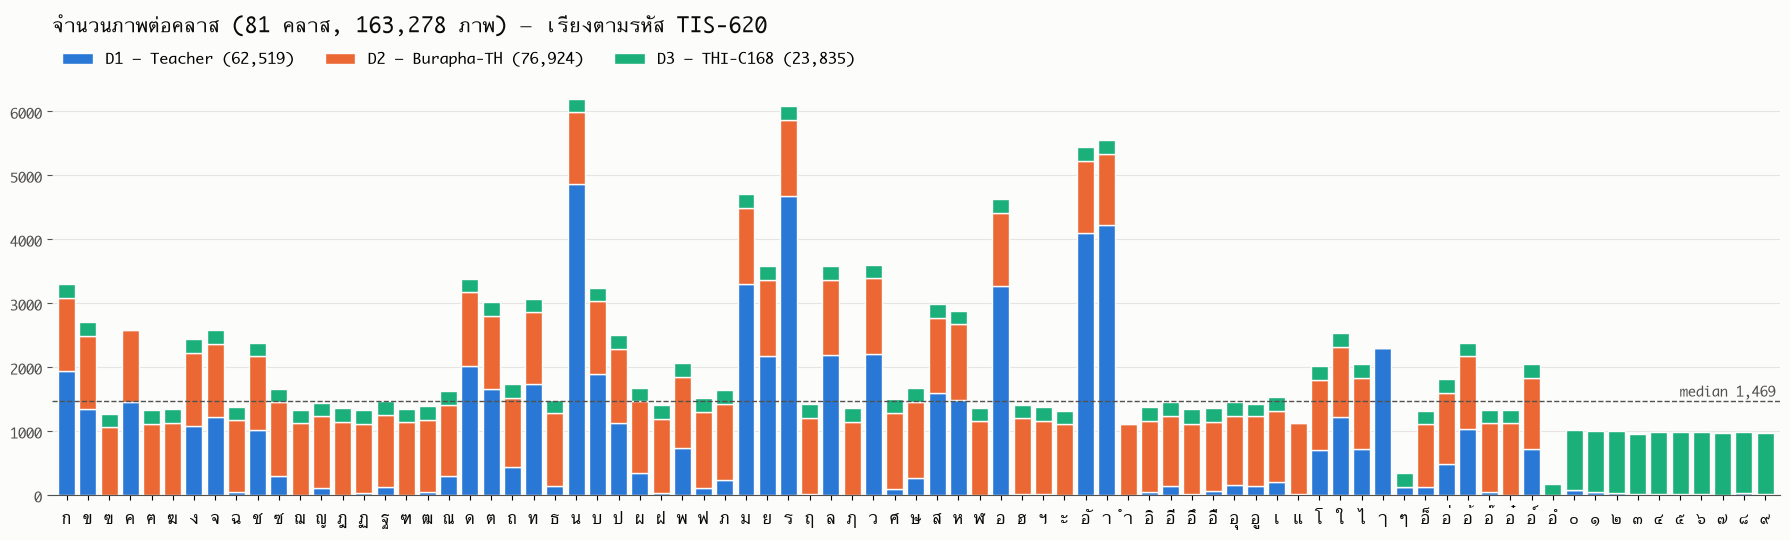

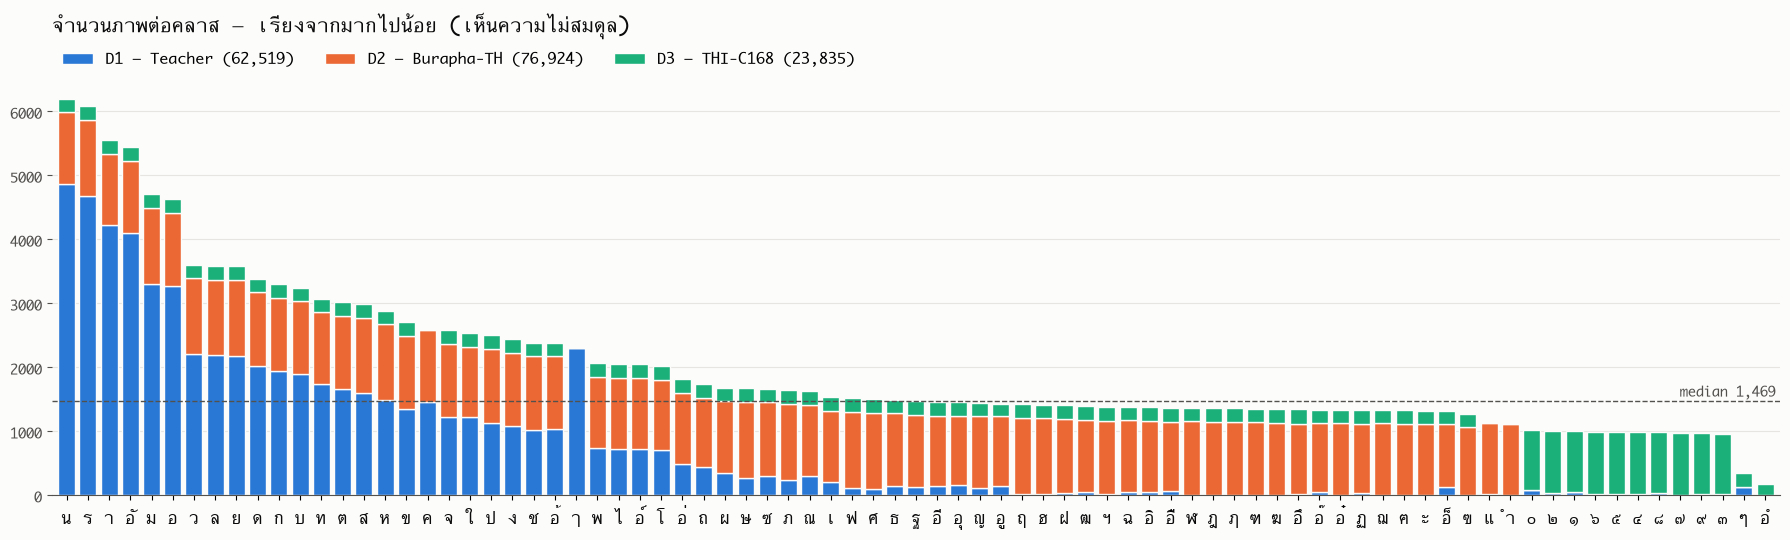

In [12]:
# (4) กราฟ stacked bar: จำนวนภาพต่อคลาส แยกสีตาม source — บันทึกไว้ใช้ใน presentation
SRC_COLOR = {"D1": "#2a78d6", "D2": "#eb6834", "D3": "#1baf7a"}   # categorical slot 1-3 (validated)
INK, INK2, GRID, SURF = "#0b0b0b", "#52514e", "#e6e5e1", "#fcfcfb"

def disp(ch):
    """สระบน/ล่าง/วรรณยุกต์เป็น combining mark (Mn) -> เกาะกับ อ ตามแบบเรียนไทย (อั อิ อ่) ให้แสดงผลได้"""
    return "อ" + ch if unicodedata.category(ch) == "Mn" else ch

def plot_counts(order, title, fname):
    fig, ax = plt.subplots(figsize=(18, 5.5), facecolor=SURF); ax.set_facecolor(SURF)
    x, bottom = np.arange(len(order)), np.zeros(len(order))
    for j, s in enumerate(SRCS):
        v = counts[order, j]
        ax.bar(x, v, 0.8, bottom=bottom, color=SRC_COLOR[s], edgecolor=SURF, linewidth=1,
               label=f"{s} — {SOURCE_NAME[s]} ({counts[:, j].sum():,})")
        bottom += v
    med = np.median(totals)
    ax.axhline(med, color=INK2, lw=1, ls="--"); ax.text(len(order) - 0.5, med, f" median {int(med):,}", va="bottom", ha="right", color=INK2, fontsize=10)
    ax.set_xticks(x, [disp(IDX_TO_CHAR[i]) for i in order], fontsize=13, color=INK)
    ax.set_xlim(-0.7, len(order) - 0.3)
    ax.tick_params(axis="y", colors=INK2)   # หน่วยแกน y อยู่ในชื่อกราฟ (ข้อความไทยแนวตั้งแสดงผลเพี้ยน)
    ax.yaxis.grid(True, color=GRID, lw=0.8); ax.set_axisbelow(True)
    for sp in ["top", "right", "left"]: ax.spines[sp].set_visible(False)
    ax.spines["bottom"].set_color(INK2)
    ax.set_title(title, loc="left", fontsize=15, color=INK, pad=34)
    ax.legend(frameon=False, loc="lower left", ncol=3, fontsize=11, bbox_to_anchor=(0, 1.0), borderaxespad=0.3)
    plt.tight_layout(); plt.savefig(OUT_DIR / fname, dpi=150, facecolor=SURF); plt.show()

plot_counts(np.arange(NUM_CLASSES), f"จำนวนภาพต่อคลาส ({NUM_CLASSES} คลาส, {totals.sum():,} ภาพ) — เรียงตามรหัส TIS-620", "class_counts_by_code.png")
plot_counts(np.argsort(-totals), "จำนวนภาพต่อคลาส — เรียงจากมากไปน้อย (เห็นความไม่สมดุล)", "class_counts_sorted.png")

### สรุปผลขั้นที่ 4
- TIS-620: 161→ก, 206→ฮ, 240→๐, 249→๙ ถูกต้อง · ทั้ง 81 คลาสตรงกับสูตร Unicode `U+0E00 + (code − 0xA0)` (224 → เ ถูกต้องตามมาตรฐาน)
- รวม **163,278 ภาพ / 81 คลาส** (D1 62,519 · D2 76,924 · D3 23,835) · median 1,469/คลาส · min ํ 173 · max น 6,190 → **imbalance 35.8×**
- **คลาสน้อยผิดปกติ**: ํ (173), ๆ (349) — ต่ำกว่าครึ่ง median
- **คลาสที่มี source เดียว**: ำ (D2 เท่านั้น), ๅ (D1 เท่านั้น)
- ⚠️ D1 `229 ๅ` (2,306 ภาพ) หน้าตาเหมือน `210 า` แทบทุกภาพ → สงสัย label/ความหมาย ต้องเช็คกับทีม
- ความไม่สมดุลมาจาก D1: พยัญชนะที่ใช้บ่อย (น ร ม อ) + า ั มีภาพ 3,000–4,800 แต่ตัวหายาก (ฃ ฅ ฎ ฑ ฬ ะ) มี 0–7 ภาพ · ตัวเลขมาจาก D3 เกือบทั้งหมด (~1,000/คลาส)
- ไฟล์: `outputs/class_counts.csv`, `outputs/class_counts_by_code.png`, `outputs/class_counts_sorted.png`

## ขั้นที่ 5 — Training (ResNet-50 transfer learning, 81 คลาส)
ใช้ของจากขั้น 1–4 ต่อ: `samples`, `NUM_CLASSES`, `IDX_TO_CHAR`, `CLASS_CODES`, `preprocess()`, `BLANK`, `device`

| ส่วน | ตัวเลือก |
|---|---|
| Split | stratified 80/20 ตาม label (ตัดภาพว่าง 3 ภาพ) |
| Input | `preprocess()` 64×64 ทำใน `__getitem__` (on-the-fly) + RAM cache ร่วมระหว่าง worker |
| Augment (train เท่านั้น) | RandomAffine → ElasticTransform → RandomErasing |
| Model | ResNet-50 ImageNet (IMAGENET1K_V2), conv1 1-channel (รวม weight RGB), FC → 81 |
| Loss / Opt / LR | CrossEntropy(label_smoothing=0.1) / AdamW / CosineAnnealingLR |
| Checkpoint | เซฟเฉพาะตอน val macro F1 ดีที่สุด |

In [13]:
# 5.1 Config — ปรับตรงนี้ที่เดียว
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as T
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

SEED        = 42
VAL_SIZE    = 0.20
EPOCHS      = 15
BATCH_SIZE  = 128
LR          = 5e-4
WEIGHT_DECAY = 1e-2
LABEL_SMOOTHING = 0.1
INPUT_SIZE  = 128        # ขยาย 64 -> 128 บน GPU ใน model (ResNet-50 ย่อ 32 เท่า: 64 จะเหลือ feature map แค่ 2×2)
NUM_WORKERS = 6          # M4 มี 10 core; ถ้า DataLoader ค้าง/crash ให้ตั้งเป็น 0
USE_CACHE   = True       # เก็บผล preprocess() ใน RAM (~0.7 GB) ให้ epoch 2+ เร็วขึ้น
USE_AMP     = True       # bfloat16 autocast บน MPS; ถ้ามี error/NaN ให้ตั้ง False
SMOKE_TEST  = False      # True = ทดลองรันเร็วด้วยข้อมูล 2% และ 1 epoch เพื่อเช็คว่าโค้ดไม่พัง

GRAY_MEAN, GRAY_STD = 0.449, 0.226     # ค่าเฉลี่ย mean/std RGB ของ ImageNet (ดูเหตุผลใน 5.4)
CKPT_DIR  = PROJECT_ROOT / "checkpoints"; CKPT_DIR.mkdir(exist_ok=True)
CKPT_PATH = CKPT_DIR / "best_resnet50.pt"

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f"device = {device} | NUM_CLASSES = {NUM_CLASSES} | checkpoint -> {CKPT_PATH.relative_to(PROJECT_ROOT)}")

device = mps | NUM_CLASSES = 81 | checkpoint -> checkpoints/best_resnet50.pt


In [14]:
# 5.2 Stratified split 80/20 ตาม label
usable = [(p, y, s) for p, y, s in samples if p not in BLANK]     # ตัดภาพว่าง 3 ภาพจากขั้น 3
all_idx = np.arange(len(usable))
all_y   = np.array([y for _, y, _ in usable])

train_idx, val_idx = train_test_split(all_idx, test_size=VAL_SIZE, stratify=all_y, random_state=SEED)
if SMOKE_TEST:
    train_idx, val_idx = train_idx[::50], val_idx[::50]

tr_cnt = np.bincount(all_y[train_idx], minlength=NUM_CLASSES)
va_cnt = np.bincount(all_y[val_idx],   minlength=NUM_CLASSES)
print(f"train {len(train_idx):,} | val {len(val_idx):,} | สัดส่วน val = {len(val_idx) / (len(train_idx) + len(val_idx)):.1%}")
print(f"ภาพ val ต่อคลาส: min {va_cnt.min()} ({IDX_TO_CHAR[va_cnt.argmin()]}) | max {va_cnt.max()} ({IDX_TO_CHAR[va_cnt.argmax()]})")
assert (va_cnt > 0).all(), "มีคลาสที่ไม่มีภาพใน val"
print("สัดส่วน val/ทั้งหมด ต่อคลาส:", f"{(va_cnt / (tr_cnt + va_cnt)).min():.3f}–{(va_cnt / (tr_cnt + va_cnt)).max():.3f}")

train 130,622 | val 32,656 | สัดส่วน val = 20.0%
ภาพ val ต่อคลาส: min 34 (ํ) | max 1238 (น)
สัดส่วน val/ทั้งหมด ต่อคลาส: 0.197–0.201


In [15]:
# 5.3 Dataset + Augmentation
# preprocess() ทำใน __getitem__ ไม่ได้ทำล่วงหน้าเป็นไฟล์ ผลเก็บใน RAM cache แบบ shared memory
# (สร้างก่อน fork worker ทุก worker จึงเขียน/อ่านก้อนเดียวกัน) epoch แรกช้า ตั้งแต่ epoch 2 อ่านจาก RAM
# augmentation ทำหลังดึงจาก cache ทุกครั้ง ภาพจึงยังสุ่มใหม่ทุก epoch (dynamic)
if USE_CACHE:
    CACHE  = torch.zeros((len(usable), TARGET, TARGET), dtype=torch.uint8).share_memory_()
    CACHED = torch.zeros(len(usable), dtype=torch.bool).share_memory_()

# ภาพหมึก=255 พื้น=0 จึงใช้ fill=0 (สีพื้น) ทุกตัว และห้าม flip เพราะตัวอักษรกลับซ้ายขวาจะกลายเป็นอีกตัว
train_tf = T.Compose([
    T.RandomAffine(degrees=10, translate=(0.08, 0.08), scale=(0.85, 1.10), shear=8,
                   interpolation=T.InterpolationMode.BILINEAR, fill=0),
    T.RandomApply([T.ElasticTransform(alpha=30.0, sigma=5.0, fill=0)], p=0.3),   # ลายมือบิดเบี้ยวเล็กน้อย
    T.ToDtype(torch.float32, scale=True),                                         # uint8 -> [0,1]
    T.RandomErasing(p=0.25, scale=(0.02, 0.08), ratio=(0.3, 3.3), value=0.0),     # ลบเป็นสีพื้น (ทำก่อน normalize)
    T.Normalize([GRAY_MEAN], [GRAY_STD]),
])
val_tf = T.Compose([
    T.ToDtype(torch.float32, scale=True),
    T.Normalize([GRAY_MEAN], [GRAY_STD]),
])

class ThaiCharDataset(Dataset):
    def __init__(self, indices, transform):
        self.indices, self.transform = np.asarray(indices), transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        j = int(self.indices[i])                      # index ใน usable (ใช้ร่วมกับ cache)
        path, label, _ = usable[j]
        if USE_CACHE and CACHED[j]:
            img = CACHE[j]
        else:
            img = torch.from_numpy(preprocess(path))
            if USE_CACHE: CACHE[j] = img; CACHED[j] = True
        return self.transform(img.unsqueeze(0)), label  # (1, 64, 64)

def _worker_init(_):
    cv2.setNumThreads(0); torch.set_num_threads(1)    # กัน thread ซ้อนใน worker (opencv/torch)

# notebook บน macOS: start method ปกติคือ spawn ซึ่งหาคลาส/ฟังก์ชันที่ประกาศใน notebook ไม่เจอ -> ใช้ fork
loader_kw = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, worker_init_fn=_worker_init)
if NUM_WORKERS > 0:
    loader_kw.update(multiprocessing_context="fork", persistent_workers=True, prefetch_factor=4)
train_loader = DataLoader(ThaiCharDataset(train_idx, train_tf), shuffle=True, drop_last=True, **loader_kw)
val_loader   = DataLoader(ThaiCharDataset(val_idx,   val_tf),   shuffle=False, **loader_kw)
print(f"train batches {len(train_loader)} | val batches {len(val_loader)}")

train batches 1020 | val batches 256


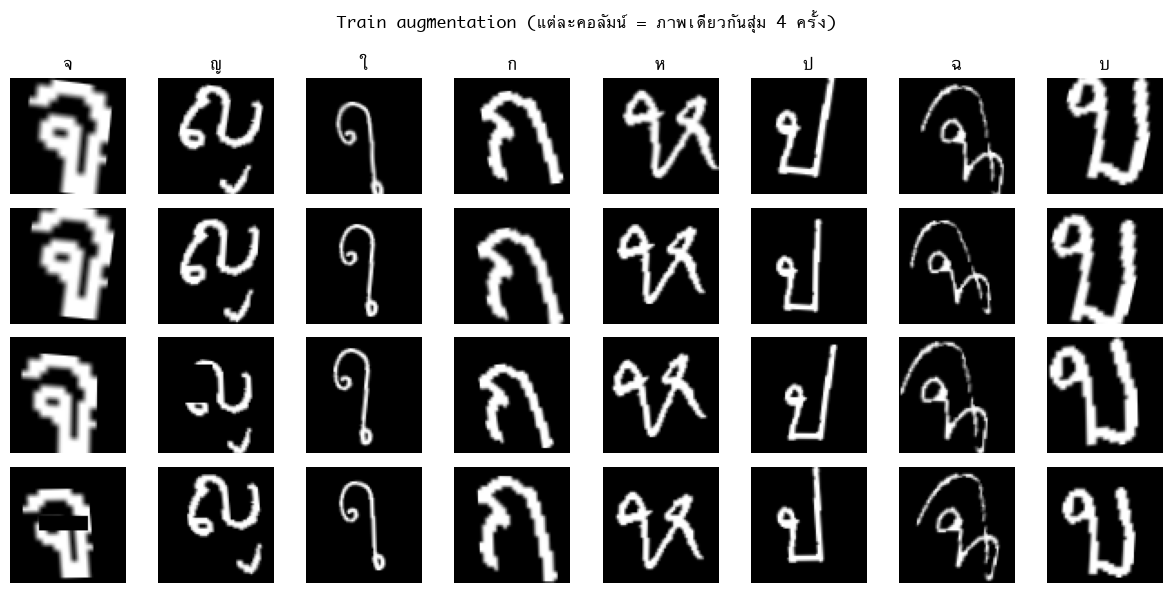

In [16]:
# 5.3.1 ดูตัวอย่างภาพหลัง augmentation (เช็คว่า augment ไม่แรงจนอ่านไม่ออก) — ใช้ num_workers=0 ไม่กระทบ loader หลัก
_ds = ThaiCharDataset(train_idx[:8], train_tf)
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for c in range(8):
    for r in range(4):                               # ภาพเดียวกัน 4 แบบสุ่ม
        x, y = _ds[c]
        axes[r, c].imshow(x[0] * GRAY_STD + GRAY_MEAN, cmap="gray", vmin=0, vmax=1); axes[r, c].axis("off")
    axes[0, c].set_title(disp(IDX_TO_CHAR[y]), fontsize=13)
plt.suptitle("Train augmentation (แต่ละคอลัมน์ = ภาพเดียวกันสุ่ม 4 ครั้ง)"); plt.tight_layout()
plt.savefig(OUT_DIR / "augmentation_examples.png", dpi=120); plt.show()

### 5.4 Model — ทำไมแก้ conv1 เป็น 1-channel แทนการ repeat ภาพเป็น 3-channel
- conv เป็นฟังก์ชันเชิงเส้น ถ้า input 3 ช่องเหมือนกันหมด (repeat) จะได้ `Σ_c W_c * x = (Σ_c W_c) * x`
  การรวม weight ของ conv1 เดิมตามแกน RGB มาเป็น filter 1-channel จึง **ได้ผลลัพธ์เท่ากับการ repeat ทุกประการ**
  pretrained weight ถูกใช้ครบ ไม่มีส่วนไหนสุ่มใหม่
- แต่ไม่ต้องสร้าง tensor 3 เท่าในทุก batch ประหยัด memory/bandwidth ของ input และ conv1
- ความเท่ากันนี้เป็นจริงเมื่อ normalize ทั้ง 3 ช่องด้วยค่าเดียวกัน จึงใช้ mean/std เดียว (ค่าเฉลี่ยของ RGB ImageNet: 0.449 / 0.226)
- ส่วนการสุ่ม conv1 1-channel ใหม่ (อีกทางเลือก) จะทิ้ง filter ขอบ/เส้นที่ pretrained เรียนมาแล้ว ซึ่งเป็นส่วนที่มีประโยชน์ที่สุดกับภาพลายเส้น

ขยายภาพ 64→128 ใน `forward` (bilinear บน GPU) เพราะ ResNet-50 ย่อภาพ 32 เท่า ภาพ 64 จะเหลือ feature map 2×2 เล็กเกินไปสำหรับแยกรายละเอียดเช่น หัวตัวอักษร หรือ ่ กับ ้
ใส่ไว้ใน model เลย ตอน inference จึงไม่ต้องจำขั้นนี้แยก

In [17]:
# 5.4 ResNet-50 pretrained -> 1-channel input, 81 output
class ThaiHCRNet(nn.Module):
    def __init__(self, num_classes, input_size=INPUT_SIZE, pretrained=True):
        super().__init__()
        net = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2 if pretrained else None)
        old = net.conv1                                          # Conv2d(3, 64, 7, stride 2)
        net.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            net.conv1.weight.copy_(old.weight.sum(dim=1, keepdim=True))   # เท่ากับการ repeat gray -> RGB
        net.fc = nn.Linear(net.fc.in_features, num_classes)     # 2048 -> 81 (สุ่มใหม่)
        self.net, self.input_size = net, input_size
    def forward(self, x):                                        # x: (B, 1, 64, 64) normalize แล้ว
        if x.shape[-1] != self.input_size:
            x = F.interpolate(x, size=(self.input_size, self.input_size), mode="bilinear", align_corners=False)
        return self.net(x)

model = ThaiHCRNet(NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
epochs    = 1 if SMOKE_TEST else EPOCHS
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)   # step ทุก epoch

n_params = sum(p.numel() for p in model.parameters())
print(f"ResNet-50 (ImageNet) params {n_params / 1e6:.1f}M | conv1 {tuple(model.net.conv1.weight.shape)} | fc {tuple(model.net.fc.weight.shape)}")

ResNet-50 (ImageNet) params 23.7M | conv1 (64, 1, 7, 7) | fc (81, 2048)


In [17]:
# 5.5 Training loop — log loss / accuracy / macro F1 ทุก epoch, เซฟ checkpoint เฉพาะตอน val macro F1 ดีที่สุด
def run_epoch(loader, train: bool):
    model.train(train)
    total_loss, y_true, y_pred = 0.0, [], []
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            with torch.autocast(device_type=device, dtype=torch.bfloat16, enabled=USE_AMP):
                logits = model(x)
                loss = criterion(logits.float(), y)
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(y)
            y_true.append(y.cpu()); y_pred.append(logits.argmax(1).cpu())
    y_true, y_pred = torch.cat(y_true).numpy(), torch.cat(y_pred).numpy()
    return {"loss": total_loss / len(y_true),
            "acc":  float((y_true == y_pred).mean()),
            "f1":   f1_score(y_true, y_pred, average="macro", labels=range(NUM_CLASSES), zero_division=0)}

history, best_f1 = [], -1.0
for epoch in range(1, epochs + 1):
    t0 = time.perf_counter()
    tr = run_epoch(train_loader, train=True)     # train metrics คิดบนภาพที่ augment แล้ว
    va = run_epoch(val_loader,   train=False)
    lr_now = optimizer.param_groups[0]["lr"]; scheduler.step()
    row = {"epoch": epoch, "lr": lr_now, **{f"train_{k}": v for k, v in tr.items()}, **{f"val_{k}": v for k, v in va.items()}}
    history.append(row)

    improved = va["f1"] > best_f1
    if improved:
        best_f1 = va["f1"]
        torch.save({                                   # เก็บทุกอย่างที่ inference ต้องใช้ ไม่ต้องพึ่ง notebook
            "model_state": model.state_dict(), "epoch": epoch, "val_f1": va["f1"], "val_acc": va["acc"],
            "num_classes": NUM_CLASSES, "class_codes": CLASS_CODES, "idx_to_char": IDX_TO_CHAR,
            "input_size": INPUT_SIZE, "target": TARGET, "gray_mean": GRAY_MEAN, "gray_std": GRAY_STD,
        }, CKPT_PATH)

    with open(OUT_DIR / "train_history.csv", "w", newline="") as fh:   # เขียนทับทุก epoch เผื่อหยุดกลางทาง
        w = csv.DictWriter(fh, fieldnames=list(row)); w.writeheader(); w.writerows(history)

    print(f"[{epoch:>2}/{epochs}] {time.perf_counter() - t0:5.0f}s lr {lr_now:.1e} | "
          f"train loss {tr['loss']:.3f} acc {tr['acc']:.4f} F1 {tr['f1']:.4f} | "
          f"val loss {va['loss']:.3f} acc {va['acc']:.4f} F1 {va['f1']:.4f}" + ("  * saved best" if improved else ""))

best = max(history, key=lambda r: r["val_f1"])
print(f"\nbest epoch {best['epoch']}: val macro F1 {best['val_f1']:.4f} | val acc {best['val_acc']:.4f} -> {CKPT_PATH.relative_to(PROJECT_ROOT)}")

[ 1/15]  1115s lr 5.0e-04 | train loss 1.072 acc 0.9005 F1 0.8822 | val loss 0.923 acc 0.9418 F1 0.9285  * saved best
[ 2/15]  1235s lr 4.9e-04 | train loss 0.909 acc 0.9472 F1 0.9347 | val loss 0.897 acc 0.9520 F1 0.9387  * saved best
[ 3/15]  1265s lr 4.8e-04 | train loss 0.886 acc 0.9543 F1 0.9433 | val loss 0.888 acc 0.9520 F1 0.9383
[ 4/15]  1276s lr 4.5e-04 | train loss 0.872 acc 0.9594 F1 0.9500 | val loss 0.874 acc 0.9580 F1 0.9490  * saved best
[ 5/15]  1318s lr 4.2e-04 | train loss 0.862 acc 0.9623 F1 0.9537 | val loss 0.873 acc 0.9573 F1 0.9454
[ 6/15]  1446s lr 3.8e-04 | train loss 0.850 acc 0.9663 F1 0.9590 | val loss 0.863 acc 0.9617 F1 0.9544  * saved best
[ 7/15]  1453s lr 3.3e-04 | train loss 0.840 acc 0.9697 F1 0.9630 | val loss 0.857 acc 0.9628 F1 0.9545  * saved best
[ 8/15]  1372s lr 2.8e-04 | train loss 0.831 acc 0.9729 F1 0.9668 | val loss 0.851 acc 0.9655 F1 0.9586  * saved best
[ 9/15]  1335s lr 2.2e-04 | train loss 0.822 acc 0.9760 F1 0.9707 | val loss 0.847 a

NameError: name 'best' is not defined

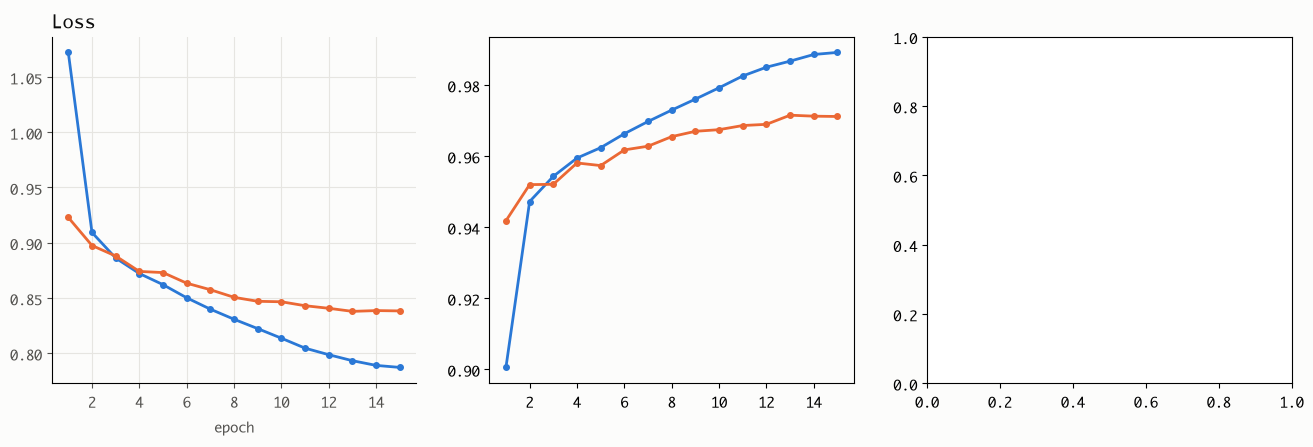

In [20]:
# 5.6 กราฟ training (สำหรับ presentation) -> outputs/training_curves.png
TRAIN_C, VAL_C = "#2a78d6", "#eb6834"          # categorical slot 1-2
ep = [r["epoch"] for r in history]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), facecolor=SURF)
for ax, key, name in zip(axes, ["loss", "acc", "f1"], ["Loss", "Accuracy", "Macro F1"]):
    ax.set_facecolor(SURF)
    ax.plot(ep, [r[f"train_{key}"] for r in history], color=TRAIN_C, lw=2, marker="o", ms=4, label="train (augmented)")
    ax.plot(ep, [r[f"val_{key}"] for r in history],   color=VAL_C,   lw=2, marker="o", ms=4, label="validation")
    if key != "loss":
        ax.axvline(best["epoch"], color=INK2, lw=1, ls="--")
        ax.annotate(f"best val {best[f'val_{key}']:.4f}", (best["epoch"], best[f"val_{key}"]),
                    textcoords="offset points", xytext=(-6, -16), ha="right", color=INK2, fontsize=10)
    ax.set_title(name, loc="left", fontsize=13, color=INK); ax.set_xlabel("epoch", color=INK2)
    ax.tick_params(colors=INK2); ax.grid(True, color=GRID, lw=0.8); ax.set_axisbelow(True)
    for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
axes[0].legend(frameon=False)
fig.suptitle(f"ResNet-50 (ImageNet pretrained) · {NUM_CLASSES} คลาส · best epoch {best['epoch']} (เส้นประ = checkpoint ที่เซฟ)",
             x=0.01, ha="left", fontsize=14, color=INK)
plt.tight_layout(); plt.savefig(OUT_DIR / "training_curves.png", dpi=150, facecolor=SURF); plt.show()

### 5.7 ประเมิน best checkpoint แยกตาม source (D1 / D2 / D3)
ไม่ต้องเทรนใหม่ — โหลด `checkpoints/best_resnet50.pt` แล้ว inference บน validation set เดิม (เซลล์ 5.2 ต้องรันมาก่อนเพื่อให้มี `val_idx`, `val_loader`)
ตารางผลใช้รูปแบบเดียวกับ `test_phet_v2.ipynb` / `test_phet_v3.ipynb` เพื่อเทียบกันได้ตรงๆ · บันทึกลง `outputs/eval_by_source.csv`

In [18]:
# 5.7 eval แยกตาม source — ใช้ตัวแปรของไฟล์นี้เท่านั้น (usable, val_idx, val_loader, model, device)
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state"]); model.eval()

# val_loader สร้างจาก ThaiCharDataset(val_idx, val_tf) แบบ shuffle=False -> ลำดับ batch ตรงกับ val_idx
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in val_loader:
        with torch.autocast(device_type=device, dtype=torch.bfloat16, enabled=USE_AMP):
            logits = model(x.to(device))
        y_true.append(y); y_pred.append(logits.argmax(1).cpu())
y_true = torch.cat(y_true).numpy()
y_pred = torch.cat(y_pred).numpy()

val_src = np.array([usable[j][2] for j in val_idx])          # source ของแต่ละภาพใน val (usable = (path, label, source))
assert len(val_src) == len(y_true) == len(y_pred), "จำนวนภาพไม่ตรงกับ val_idx — ต้องรันเซลล์ 5.2/5.3 ก่อน"

rows = []
for name, mask in [("ALL", np.ones(len(val_src), bool)), *[(s, val_src == s) for s in ["D1", "D2", "D3"]]]:
    yt, yp = y_true[mask], y_pred[mask]
    present = sorted(set(yt.tolist()))                        # macro F1 เฉพาะคลาสที่มีจริงใน source นั้น
    rows.append({"source": name, "desc": SOURCE_NAME.get(name, "ทั้งหมด"), "n_images": int(mask.sum()),
                 "n_classes": len(present), "accuracy": round(float((yt == yp).mean()), 4),
                 "macro_f1": round(f1_score(yt, yp, average="macro", labels=present, zero_division=0), 4)})

with open(OUT_DIR / "eval_by_source.csv", "w", newline="", encoding="utf-8-sig") as fh:   # ไฟล์ใหม่ ไม่ทับของเดิมใน outputs/
    w = csv.DictWriter(fh, fieldnames=list(rows[0])); w.writeheader(); w.writerows(rows)

print(f"best checkpoint: epoch {ckpt['epoch']} (val macro F1 ตอนเทรน {ckpt['val_f1']:.4f})\n")
print(f"{'source':<7}{'คำอธิบาย':<16}{'ภาพ':>8}{'คลาส':>7}{'accuracy':>11}{'macro F1':>11}")
for r in rows:
    print(f"{r['source']:<7}{r['desc']:<16}{r['n_images']:>8,}{r['n_classes']:>7}{r['accuracy']:>11.4f}{r['macro_f1']:>11.4f}")

best checkpoint: epoch 13 (val macro F1 ตอนเทรน 0.9671)

source คำอธิบาย             ภาพ   คลาส   accuracy   macro F1
ALL    ทั้งหมด           32,656     81     0.9715     0.9671
D1     Teacher           12,484     72     0.9897     0.9332
D2     Burapha-TH        15,443     68     0.9560     0.9580
D3     THI-C168           4,729     77     0.9740     0.9770
